# IMPORTING PACKAGES.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# DATA ANALYSIS.

In [2]:
# READ A COMMA-SEPARETED VALUES (CSV)FILE INTO PANDAS DATA FRAME.
train=pd.read_csv(r"../input/titanic/train.csv")
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
test=pd.read_csv(r"../input/titanic/test.csv")
test.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


In [4]:
# COUNT THE NUMBER OF ROWS AND COLUMNS IN THE TRAIN DATASET AND TEST DATASET.
print(train.shape)
print(test.shape)


(891, 12)
(418, 11)


In [5]:
#LOOK AT THE COLUMNS OF TRAIN DATASET AND TEST DATASET.
print(train.columns)
print(test.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [6]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# GET THE COUNT OF THE NUMBER OF SURVIOURS,SEX,EMBARKED,SIBSP,TICKET.
print(train["Survived"].value_counts())
print(train["Sex"].value_counts())
print(train["Embarked"].value_counts())
print(train["SibSp"].value_counts())
print(train["Ticket"].value_counts())

0    549
1    342
Name: Survived, dtype: int64
male      577
female    314
Name: Sex, dtype: int64
S    644
C    168
Q     77
Name: Embarked, dtype: int64
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: SibSp, dtype: int64
CA. 2343      7
1601          7
347082        7
CA 2144       6
3101295       6
             ..
SC/AH 3085    1
237671        1
11755         1
A/5 21174     1
11774         1
Name: Ticket, Length: 681, dtype: int64


In [8]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

<AxesSubplot:xlabel='Survived', ylabel='count'>

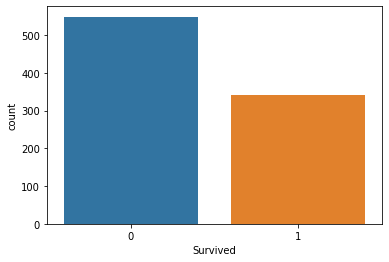

In [9]:
sns.countplot(x="Survived",data=train)

<AxesSubplot:xlabel='Sex', ylabel='count'>

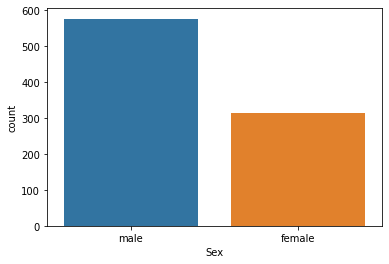

In [10]:
sns.countplot(x="Sex",data=train)

In [11]:
#LOOK AT THE SURVIVAL RATE BY SEX.
train.groupby('Sex')[['Survived']].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [12]:
#LOOK AT SURVIVAL RATE BY SEX AND PCLASS
train.pivot_table('Survived',index='Sex',columns='Pclass')

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


<AxesSubplot:xlabel='Sex'>

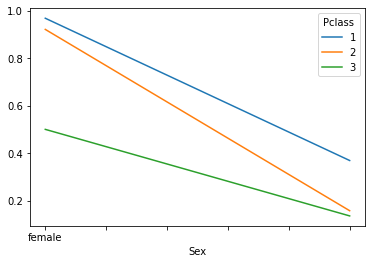

In [13]:
#LOOK AT SURVIVAL RATE BY SEX AND PCLASS VISUALLY.
train.pivot_table('Survived',index='Sex',columns='Pclass').plot()

<AxesSubplot:xlabel='Pclass', ylabel='Survived'>

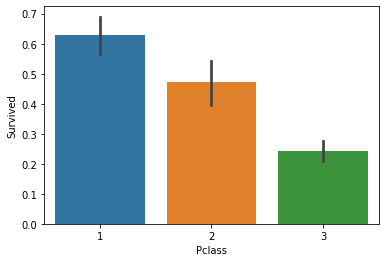

In [14]:
#PLOT THE SURVIVAL RATE OF EACH CLASS
sns.barplot(x='Pclass',y='Survived',data=train)

In [15]:
#LOOK AT SURVIVAL RATE BY SEX ,AGE AND PCLASS.
age=pd.cut(train['Age'],[0,18,80])
train.pivot_table('Survived',['Sex','Age'],'Pclass')

Pclass          1    2     3
Sex    Age                  
female 0.75   NaN  NaN  1.00
       1.00   NaN  NaN  1.00
       2.00   0.0  1.0  0.25
       3.00   NaN  1.0  0.00
       4.00   NaN  1.0  1.00
...           ...  ...   ...
male   70.00  0.0  0.0   NaN
       70.50  NaN  NaN  0.00
       71.00  0.0  NaN   NaN
       74.00  NaN  NaN  0.00
       80.00  1.0  NaN   NaN

[145 rows x 3 columns]

In [16]:
#COUNT THE EMPTY VALUES IN EACH COLUMN
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [17]:
#LOOK AT ALL OF THE VALUES IN EACH COLUMN AND GET A COUNT.
for val in train:
    print(train[val].value_counts())
    print()

1      1
599    1
588    1
589    1
590    1
      ..
301    1
302    1
303    1
304    1
891    1
Name: PassengerId, Length: 891, dtype: int64

0    549
1    342
Name: Survived, dtype: int64

3    491
1    216
2    184
Name: Pclass, dtype: int64

Lang, Mr. Fang                                     1
Ivanoff, Mr. Kanio                                 1
Rintamaki, Mr. Matti                               1
Jenkin, Mr. Stephen Curnow                         1
Allison, Mrs. Hudson J C (Bessie Waldo Daniels)    1
                                                  ..
Sunderland, Mr. Victor Francis                     1
Touma, Mrs. Darwis (Hanne Youssef Razi)            1
Sharp, Mr. Percival James R                        1
Greenberg, Mr. Samuel                              1
Stankovic, Mr. Ivan                                1
Name: Name, Length: 891, dtype: int64

male      577
female    314
Name: Sex, dtype: int64

24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
55.50

In [18]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [19]:
#PRINT THE UNIQUE VALUES IN THE COLUMNS
print(train['Sex'].unique())
print(train['Embarked'].unique())

['male' 'female']
['S' 'C' 'Q' nan]


# CLEANING THE DATASET

In [20]:
title=set()
for name in train["Name"]:
    title.add(name.split(",")[1].split(".")[0].strip())
print(title)    

{'the Countess', 'Master', 'Ms', 'Dr', 'Lady', 'Col', 'Don', 'Rev', 'Mrs', 'Mme', 'Sir', 'Miss', 'Jonkheer', 'Capt', 'Mr', 'Mlle', 'Major'}


In [21]:
titles={'Sir':"officer",'Mme':"normald",'Mr':"norm",'Master':"normald",'Don':"officer",'Miss':"normald",'Lady':"normald",'Mlle':"normald",'Col':"officer",'Ms':"normald",'the Countess':"royal",'Mrs':"normald",'Major':"officer",'Capt':"officer",'Dr':"officer",'Rev':"officer",'Jonkheer':"royal"}


In [22]:
train["Name"]=train["Name"].map(lambda name:name.split(",")[1].split(".")[0].strip())
train["Name"]=train.Name.map(titles)
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,norm,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,normald,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,normald,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,normald,female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,norm,male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,norm,male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,norm,male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,normald,male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,normald,female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,normald,female,14.0,1,0,237736,30.0708,NaN,C


In [23]:
#DROP THE UNWANTED FIELDS.
df=train.drop(["Ticket","Cabin","PassengerId"],axis=1)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,norm,male,22.0,1,0,7.2500,S
1,1,1,normald,female,38.0,1,0,71.2833,C
2,1,3,normald,female,26.0,0,0,7.9250,S
3,1,1,normald,female,35.0,1,0,53.1000,S
4,0,3,norm,male,35.0,0,0,8.0500,S


In [24]:
#CONVERTING THE STRING VALUES(CATEGORICAL VALUES) TO INTEGER
df.Sex=df.Sex.map({"female":0,"male":"1"})
df.Embarked=df.Embarked.map({"S":0,"C":"1","Q":2})
df.Name=df.Name.map({"royal":0,"normald":1,"officer":2,"norm":3})
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,3,1,22.0,1,0,7.2500,0
1,1,1,1,0,38.0,1,0,71.2833,1
2,1,3,1,0,26.0,0,0,7.9250,0
3,1,1,1,0,35.0,1,0,53.1000,0
4,0,3,3,1,35.0,0,0,8.0500,0


In [25]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [26]:
#REPLACING ALL THE NULL VALUES.
df.fillna(df.Age.mean(),inplace=True)
round(df["Age"],1)
df.head(10)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,3,1,22.000000,1,0,7.2500,0
1,1,1,1,0,38.000000,1,0,71.2833,1
2,1,3,1,0,26.000000,0,0,7.9250,0
3,1,1,1,0,35.000000,1,0,53.1000,0
4,0,3,3,1,35.000000,0,0,8.0500,0
5,0,3,3,1,29.699118,0,0,8.4583,2
6,0,1,3,1,54.000000,0,0,51.8625,0
7,0,3,1,1,2.000000,3,1,21.0750,0
8,1,3,1,0,27.000000,0,2,11.1333,0
9,1,2,1,0,14.000000,1,0,30.0708,1


In [27]:
df.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [28]:
#GET SOME STATISTICS.
df.describe()

,Survived,Pclass,Name,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,2.180696,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,0.976066,13.002015,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,1.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# FEATURE SCALLING.

In [29]:
#THE STANDARDSCALER ASSUMES DATA IS NORMALLYDISTRIBUTED WITHIN EACH FEATURE AND SCALES THEM SUCH 
#THAT THE DISTRIBUTION CENTERED AROUND 0, WITH A STANDARD DEVIATION BY 1.

from sklearn.preprocessing import StandardScaler
df["Age"]=round((df.Age-df.Age.mean()/df.Age.std()))
df["Fare"]=round((df.Fare-df.Fare.mean()/df.Fare.std()))


In [30]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,3,1,20.0,1,0,7.0,0
1,1,1,1,0,36.0,1,0,71.0,1
2,1,3,1,0,24.0,0,0,7.0,0
3,1,1,1,0,33.0,1,0,52.0,0
4,0,3,3,1,33.0,0,0,7.0,0


In [31]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,3,1,20.0,1,0,7.0,0
1,1,1,1,0,36.0,1,0,71.0,1
2,1,3,1,0,24.0,0,0,7.0,0
3,1,1,1,0,33.0,1,0,52.0,0
4,0,3,3,1,33.0,0,0,7.0,0


# DATA MODELLING

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
x_train,x_test,y_train,y_test=train_test_split(
     df.drop(["Survived"],axis=1),
     df.Survived,test_size=0.2,
     random_state=0,
     stratify=df.Survived)

# CREATE A FUNCTION WITH RANDOM FOREST CLASSIFIER MODEL

In [34]:
def models(x_train,y_train):
    # USE RANDOM FOREST CLASSIFIER
    from sklearn.ensemble import RandomForestClassifier
    forest= RandomForestClassifier(n_estimators=10,criterion='entropy',random_state=0)
    forest.fit(x_train,y_train)
    
    

    
    
    #PRINT THE TRAINING ACCURACY FOR RANDOM FOREST CLASSIFIER.
    print('Random forest  training accuracy:',forest.score(x_train,y_train))
    
    return forest

In [35]:
#GET AND TRAIN RANDOM FOREST CLASSIFIER MODELS
model=models(x_train,y_train)

Random forest  training accuracy: 0.9536516853932584


# PRINT THE PREDICTION ON DECISION TREE  MODEL

In [36]:
title=set()
for name in test["Name"]:
    title.add(name.split(",")[1].split(".")[0].strip())
print(title)    

{'Master', 'Ms', 'Dr', 'Col', 'Rev', 'Mrs', 'Dona', 'Miss', 'Mr'}


In [37]:


titles={'Sir':"officer",'Mme':"normald",'Mr':"norm",'Master':"normald",'Don':"officer",'Miss':"normald",'Lady':"normald",'Mlle':"normald",'Lady':"normald",'Mlle':"normald",'Col':"officer",'Ms':"normald",'the Countess':"royal",'Mrs':"normald",'Major':"officer",'Capt':"officer",'Dr':"officer",'Rev':"officer",'Jonkheer':"royal"}

In [38]:
test["Name"]=test["Name"].map(lambda name:name.split(",")[1].split(".")[0].strip())
test["Name"]=test.Name.map(titles)
test.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,norm,male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,normald,female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,norm,male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,norm,male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,normald,female,22.0,1,1,3101298,12.2875,NaN,S
5,897,3,norm,male,14.0,0,0,7538,9.2250,NaN,S
6,898,3,normald,female,30.0,0,0,330972,7.6292,NaN,Q
7,899,2,norm,male,26.0,1,1,248738,29.0000,NaN,S
8,900,3,normald,female,18.0,0,0,2657,7.2292,NaN,C
9,901,3,norm,male,21.0,2,0,A/4 48871,24.1500,NaN,S


In [39]:
#DROPPING UNWANTED FIELDS.
df1=test.drop(["Ticket","Cabin","PassengerId"],axis=1)
df1.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,norm,male,34.5,0,0,7.8292,Q
1,3,normald,female,47.0,1,0,7.0000,S
2,2,norm,male,62.0,0,0,9.6875,Q
3,3,norm,male,27.0,0,0,8.6625,S
4,3,normald,female,22.0,1,1,12.2875,S


In [40]:
#CONVERTING THE STRING VALUES(CATEGORICAL VALUES) TO INTEGER
df1.Sex=df1.Sex.map({"female":0,"male":"1"})
df1.Embarked=df1.Embarked.map({"S":0,"C":"1","Q":2})
df1.Name=df1.Name.map({"royal":0,"normald":1,"officer":2,"norm":3})
df1.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,3.0,1,34.5,0,0,7.8292,2
1,3,1.0,0,47.0,1,0,7.0000,0
2,2,3.0,1,62.0,0,0,9.6875,2
3,3,3.0,1,27.0,0,0,8.6625,0
4,3,1.0,0,22.0,1,1,12.2875,0


In [41]:
df1.isnull().sum()

Pclass       0
Name         1
Sex          0
Age         86
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64

In [42]:
#REPLACING ALL THE NULL VALUES
df1.fillna(df1.Age.mean(),inplace=True)

In [43]:
df1.isnull().sum()

Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [44]:
df1["Age"]=round((df1.Age-df1.Age.mean()/df1.Age.std()))
df1["Fare"]=round((df1.Fare-df1.Fare.mean())/df1.Fare.std())


In [45]:
df1.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,3.0,1,32.0,0,0,-0.0,2
1,3,1.0,0,45.0,1,0,-1.0,0
2,2,3.0,1,60.0,0,0,-0.0,2
3,3,3.0,1,25.0,0,0,-0.0,0
4,3,1.0,0,20.0,1,1,-0.0,0


In [46]:
#PRINT THE PREDICTION.
pred=model.predict(df1)
pred

array([0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,